# Exploratory Data Analysis (EDA)

EDA is used for understanding and exploring a dataset. When you get some data to analyze, the first step usually is to read it, and then perform the EDA.

- During the EDA process, you will;
    - understand the data
    - visualize a lot
    - find trends
    - ask questions and try to answer them with the data
    - be curious
    - document your findings
    - data cleaning

In [1]:
import pandas as pd

df = pd.read_csv("salaries_lecture02.csv")
df.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


## Initial EDA of salaries dataset

In [2]:
# Shows number of columns
df.columns


Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [3]:
# 16534 rows, 11 columns
df.shape


(16534, 11)

In [4]:
# df.info to see if there is any null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           16534 non-null  int64
 1   experience_level    16534 non-null  str  
 2   employment_type     16534 non-null  str  
 3   job_title           16534 non-null  str  
 4   salary              16534 non-null  int64
 5   salary_currency     16534 non-null  str  
 6   salary_in_usd       16534 non-null  int64
 7   employee_residence  16534 non-null  str  
 8   remote_ratio        16534 non-null  int64
 9   company_location    16534 non-null  str  
 10  company_size        16534 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.4 MB


In [5]:
# Antal rows för varje work year. Här ser jag klart och tydligt att 2023 har flest rows på 8.5k, sen 2024 på 6k, 2022 på 1.6k
df["work_year"].value_counts()

work_year
2023    8519
2024    6067
2022    1655
2021     218
2020      75
Name: count, dtype: int64

In [6]:
# value_counts works for this as well, with .head(15) it shows me the top 15 countries with most company locations
df["company_location"].value_counts().head(15)

company_location
US    14518
GB      694
CA      455
ES      133
DE      105
FR       65
IN       63
AU       57
NL       32
PT       28
BR       22
LT       20
ZA       19
LV       16
CO       16
Name: count, dtype: int64

Change the experience level to something more readable
- SE -> Senior
- MI -> Mid
- EN -> Entry
- EX -> Expert

In [7]:
df["experience_level"].value_counts()

experience_level
SE    10670
MI     4038
EN     1325
EX      501
Name: count, dtype: int64

In [8]:
df["salary_currency"].value_counts().head(5)

salary_currency
USD    15294
GBP      616
EUR      449
CAD       56
INR       55
Name: count, dtype: int64

Is it possible to combine salary in usd with job role?
For example:
- Group by and median for each job role?


In [9]:
df["salary_in_usd"].head()

0    202730
1     92118
2    130500
3     96000
4    190000
Name: salary_in_usd, dtype: int64

Here I want to change names for the company size.
- M -> Medium
- L -> Large
- S -> Small

In [10]:
df["company_size"].value_counts()

company_size
M    15306
L     1040
S      188
Name: count, dtype: int64

Note that there are some issues with the current data. There is data scientist AND data science.
The roles are the same but written in a different way. This needs fixing!

In [15]:
df["job_title"].value_counts().head(35)

job_title
Data Engineer                               3464
Data Scientist                              3314
Data Analyst                                2440
Machine Learning Engineer                   1705
Research Scientist                           531
Applied Scientist                            435
Data Architect                               435
Analytics Engineer                           431
Research Engineer                            306
Data Science                                 271
Business Intelligence Engineer               248
Data Manager                                 212
ML Engineer                                  200
Business Intelligence Analyst                191
Machine Learning Scientist                   138
Research Analyst                             123
Data Science Manager                         122
AI Engineer                                  120
Business Intelligence                         98
BI Developer                                  90
Data Speci

## Cleaning job titles

In [12]:
import duckdb

duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data scien%'

""").df()["job_title"].value_counts()

job_title
Data Scientist               3314
Data Science                  271
Data Science Manager          122
Data Science Consultant        83
Data Science Engineer          29
Data Science Lead              26
Data Science Practitioner      16
Data Science Director           8
Data Science Analyst            4
Data Scientist Lead             2
Data Science Tech Lead          1
Name: count, dtype: int64

In [13]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data eng%'

""").df()["job_title"].value_counts()

job_title
Data Engineer    3464
Name: count, dtype: int64

In [16]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data analy%'

""").df()["job_title"].value_counts()

job_title
Data Analyst                 2440
Data Analytics Manager         62
Data Analytics Lead            23
Data Analytics Specialist       8
Data Analytics Consultant       8
Data Analytics Engineer         5
Data Analyst Lead               2
Data Analytics Associate        1
Name: count, dtype: int64

In [20]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'machine learning%engineer%'

""").df()["job_title"].value_counts()

job_title
Machine Learning Engineer                   1705
Machine Learning Infrastructure Engineer      33
Machine Learning Software Engineer            15
Machine Learning Operations Engineer           9
Machine Learning Research Engineer             5
Name: count, dtype: int64

Time to clean the dataset!

In [34]:
# df_cleaned
df_cleaned = duckdb.sql("""--sql
SELECT
    * EXCLUDE(job_title, experience_level, company_size),
    CASE
        WHEN job_title ILIKE 'data scien%' THEN 'Data Scientist'
        WHEN job_title ILIKE 'data analyn%' THEN 'Data Analyst'
        WHEN job_title ILIKE 'machine learning%engineer%' THEN 'Machine Learning Engineer'
        ELSE job_title
    END AS job_title,
    CASE 
        WHEN experience_level = 'EN' THEN 'Entry'
        WHEN experience_level = 'MI' THEN 'Middle'
        WHEN experience_level = 'SE' THEN 'Senior'
        WHEN experience_level = 'EX' THEN 'Expert'
    END AS experience_level,
    CASE
        WHEN company_size = 'M' THEN 'Medium'
        WHEN company_size = 'L' THEN 'Large'
        WHEN company_size = 'S' THEN 'Small'
    END AS company_size                        
FROM df
""").df()

df_cleaned["company_size"].value_counts().head()

company_size
Medium    15306
Large      1040
Small       188
Name: count, dtype: int64

In [41]:
df_cleaned["company_size"].value_counts()

company_size
Medium    15306
Large      1040
Small       188
Name: count, dtype: int64

## Export the cleaned dataset

In [42]:
df_cleaned.to_csv("salaries_cleaned_lecture02.csv")

## Visualizations of the cleaned data

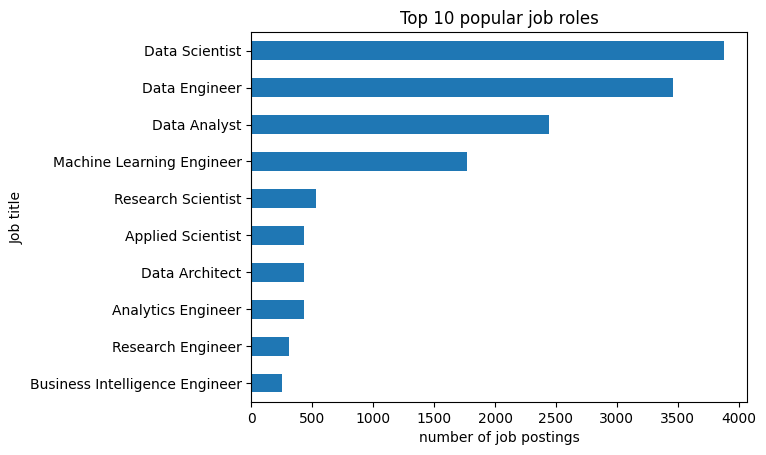

In [49]:
ax = df_cleaned["job_title"].value_counts().head(10).plot(
    kind="barh", 
    title="Top 10 popular job roles", 
    xlabel = "number of job postings",
    ylabel="Job title",
    )

ax.invert_yaxis()

In [57]:
df_cleaned.head()

,work_year,employment_type,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,job_title,experience_level,company_size
0,2024,FT,202730,USD,202730,US,0,US,AI Engineer,Senior,Medium
1,2024,FT,92118,USD,92118,US,0,US,AI Engineer,Senior,Medium
2,2024,FT,130500,USD,130500,US,0,US,Data Engineer,Senior,Medium
3,2024,FT,96000,USD,96000,US,0,US,Data Engineer,Senior,Medium
4,2024,FT,190000,USD,190000,US,0,US,Machine Learning Engineer,Senior,Medium


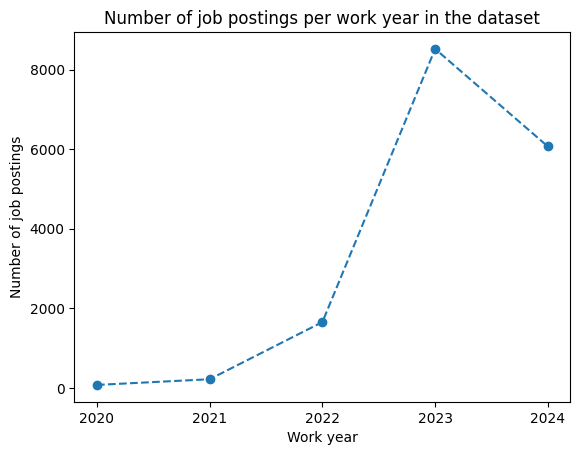

In [56]:
import matplotlib.pyplot as plt

# DataFrame_cleaned["work_year"].value_counts().sortera_index.plotta en chart()
ax = df_cleaned["work_year"].value_counts().sort_index().plot(
    linestyle="--", 
    marker="o", 
    xlabel="Work year", 
    ylabel="Number of job postings",
    title="Number of job postings per work year in the dataset",
    )

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))